<a href="https://colab.research.google.com/github/Parthwadekar40/Parth40-MachineVision/blob/main/Prac3_MV_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please select and upload your product inspection image:


Saving images (1).jpeg to images (1) (1).jpeg
Loaded image: images (1) (1).jpeg (447x447 px)
Calibration successful with Leftmost object!
Computed Scale: 2.150 pixels per mm

Product #1: Size = 20.0mm x 38.1mm
Product #2: Size = 37.2mm x 22.0mm
Product #3: Size = 66.6mm x 107.3mm
Product #4: Size = 32.4mm x 16.9mm
Product #5: Size = 87.0mm x 19.7mm
Product #6: Size = 46.5mm x 17.8mm
Product #7: Size = 33.5mm x 28.4mm
Product #8: Size = 26.1mm x 38.6mm


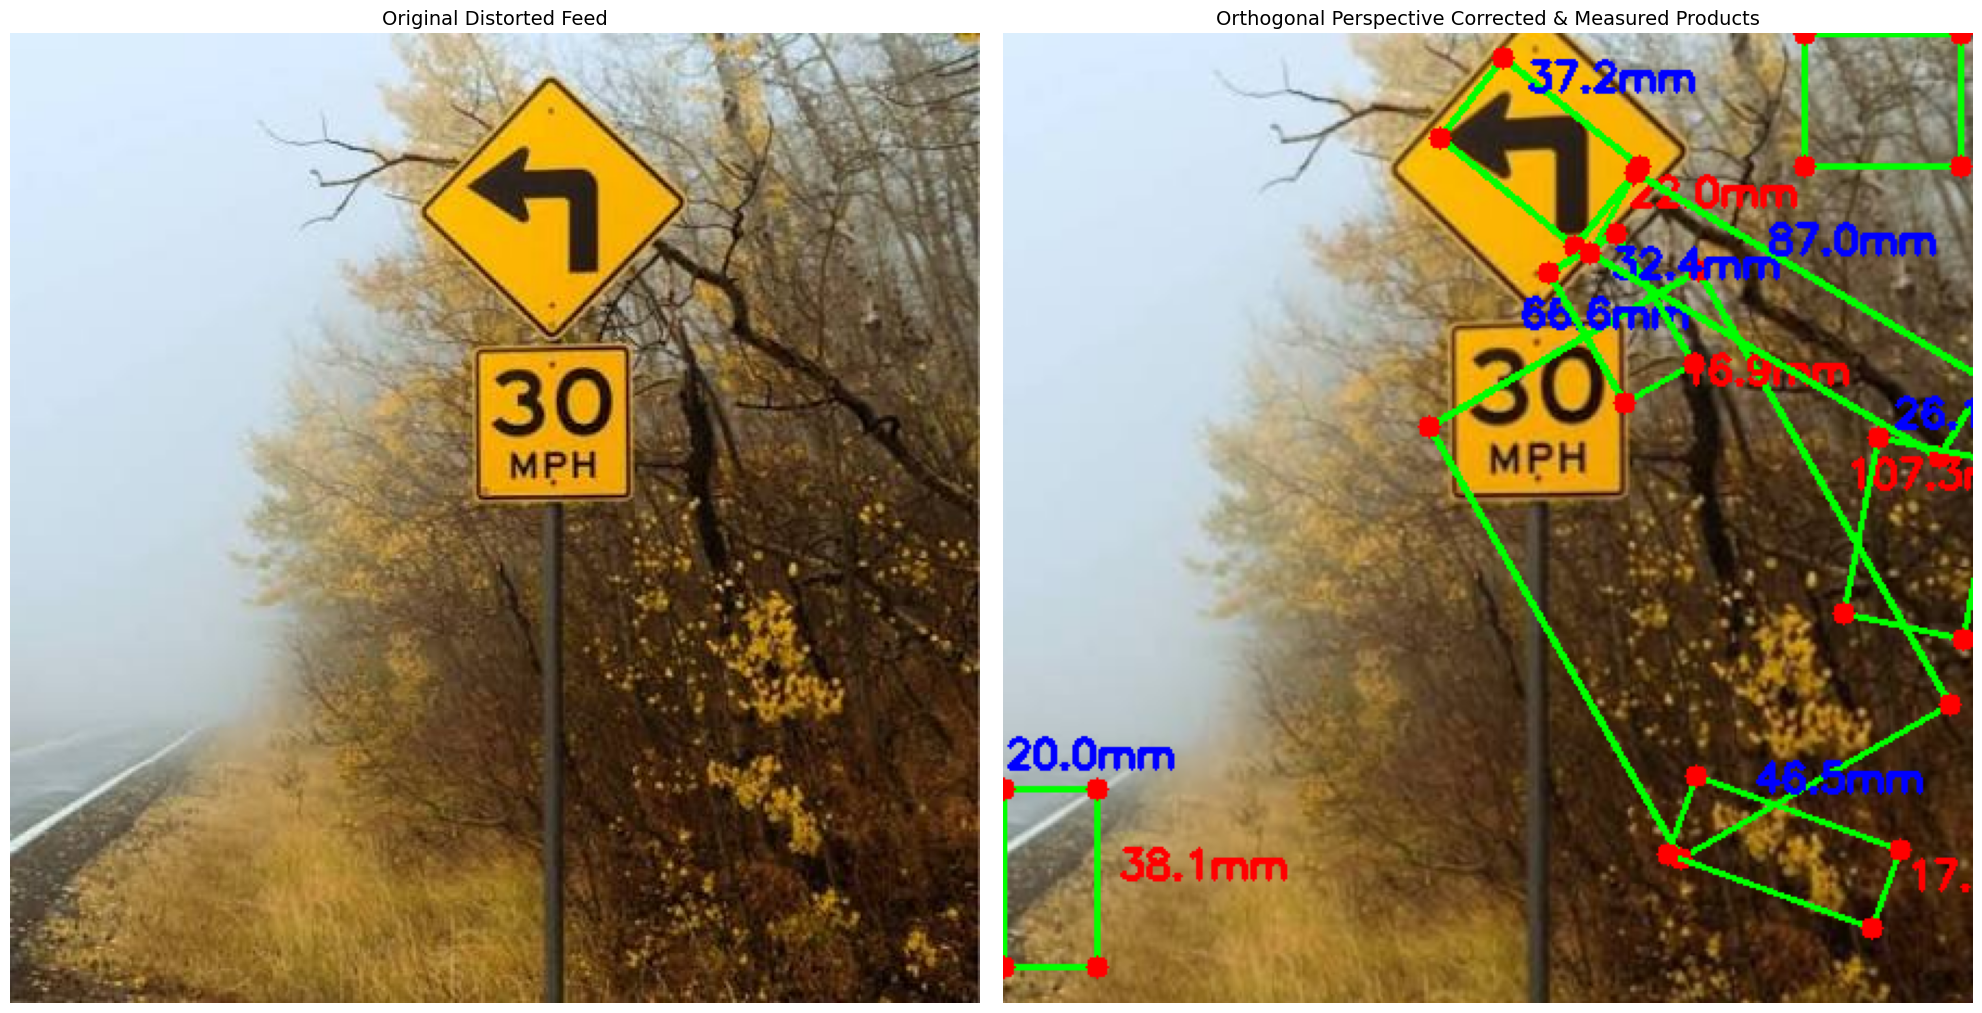

In [3]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from scipy.spatial import distance as dist

def order_points(pts):
    """Sorts coordinates consistently: top-left, top-right, bottom-right, bottom-left."""
    x_sorted = pts[np.argsort(pts[:, 0]), :]
    left_most = x_sorted[:2, :]
    right_most = x_sorted[2:, :]

    left_most = left_most[np.argsort(left_most[:, 1]), :]
    (tl, bl) = left_most

    right_most = right_most[np.argsort(right_most[:, 1]), :]
    (tr, br) = right_most

    return np.array([tl, tr, br, bl], dtype="float32")

def midpoint(ptA, ptB):
    """Calculates the 2D midpoint between two coordinate points."""
    return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

# --- Configuration for Metrology ---
# We assume the leftmost object in the image is our calibration standard.
# Change this value to match your actual reference object's physical width (in mm).
REFERENCE_WIDTH_MM = 20.0

# 1. Upload File from Local Computer
print("Please select and upload your product inspection image:")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    image_bytes = uploaded[file_name]

    # Decode image to BGR format
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    h, w = img.shape[:2]

    print(f"Loaded image: {file_name} ({w}x{h} px)")

    # 2. Correct Perspective Distortion (Affine/Homography Transformation)
    # Define 4 source coordinates mapping a skewed perspective to an orthogonal flat plane
    # If your camera is flat, keep src and dst points aligned.
    src_pts = np.float32([
        [int(w * 0.05), int(h * 0.05)],  # Top-Left
        [int(w * 0.95), int(h * 0.08)],  # Top-Right (Simulates slight camera tilt)
        [int(w * 0.95), int(h * 0.92)],  # Bottom-Right
        [int(w * 0.05), int(h * 0.95)]   # Bottom-Left
    ])

    dst_pts = np.float32([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ])

    # Perform Perspective Warp (Advanced Homography)
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped_img = cv2.warpPerspective(img, M, (w, h))

    # 3. Image Pre-processing for Object Segmentation
    gray = cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)

    # Adaptive thresholding to isolate foreground targets cleanly
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    # Morphological opening and closing to remove noise and fill internal holes
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    # 4. Extract Structural Contours
    contours, _ = cv2.findContours(cleaned.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        print("Error: No objects detected. Adjust lighting or check the thresholding settings.")
    else:
        # Sort contours from left-to-right (the leftmost detected object is treated as calibration)
        boundingBoxes = [cv2.boundingRect(c) for c in contours]
        (contours, _) = zip(*sorted(zip(contours, boundingBoxes), key=lambda b: b[1][0]))

        pixels_per_metric = None
        annotated_img = warped_img.copy()
        valid_objects_count = 0

        for idx, c in enumerate(contours):
            # Ignore tiny structural fragments and edge noises
            if cv2.contourArea(c) < 1000:
                continue

            valid_objects_count += 1

            # Find the minimum area bounding box (handles object rotation/skew on plane)
            rect = cv2.minAreaRect(c)
            box = cv2.boxPoints(rect)
            box = np.array(box, dtype="int")

            # Reorder box points consistently
            box = order_points(box)

            # Draw green bounding boxes around detected components
            cv2.drawContours(annotated_img, [box.astype("int")], -1, (0, 255, 0), 2)

            # Draw corner markers
            for (x, y) in box:
                cv2.circle(annotated_img, (int(x), int(y)), 5, (0, 0, 255), -1)

            (tl, tr, br, bl) = box

            # Calculate midpoints for length and width lines
            (tltrX, tltrY) = midpoint(tl, tr)
            (blbrX, blbrY) = midpoint(bl, br)
            (tlblX, tlblY) = midpoint(tl, bl)
            (trbrX, trbrY) = midpoint(tr, br)

            # Calculate Euclidean distance in pixels
            height_pixels = dist.euclidean((tltrX, tltrY), (blbrX, blbrY))
            width_pixels = dist.euclidean((tlblX, tlblY), (trbrX, trbrY))

            # 5. Determine calibration factor using the leftmost (first valid) object
            if pixels_per_metric is None:
                pixels_per_metric = width_pixels / REFERENCE_WIDTH_MM
                print(f"Calibration successful with Leftmost object!")
                print(f"Computed Scale: {pixels_per_metric:.3f} pixels per mm\n")

            # Convert pixel measurements to physical units (mm)
            measured_height_mm = height_pixels / pixels_per_metric
            measured_width_mm = width_pixels / pixels_per_metric

            # Render dimension text on the image
            # Width label (Blue)
            cv2.putText(
                annotated_img, f"{measured_width_mm:.1f}mm",
                (int(tltrX) - 20, int(tltrY) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
            )
            # Height label (Red)
            cv2.putText(
                annotated_img, f"{measured_height_mm:.1f}mm",
                (int(trbrX) + 10, int(trbrY)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2
            )

            print(f"Product #{valid_objects_count}: Size = {measured_width_mm:.1f}mm x {measured_height_mm:.1f}mm")

        # 6. Plot Results side-by-side
        plt.figure(figsize=(20, 10))

        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Distorted Feed", fontsize=14)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
        plt.title("Orthogonal Perspective Corrected & Measured Products", fontsize=14)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

else:
    print("Execution aborted. No file selected.")